Processing ID LC: Image = /sibcb1/chenluonanlab8/zoujiawei/data_lung/10x/10x/images/LC.png, Spatial Data = /sibcb1/chenluonanlab8/zoujiawei/data_lung/10x/10x/spot_LC.csv


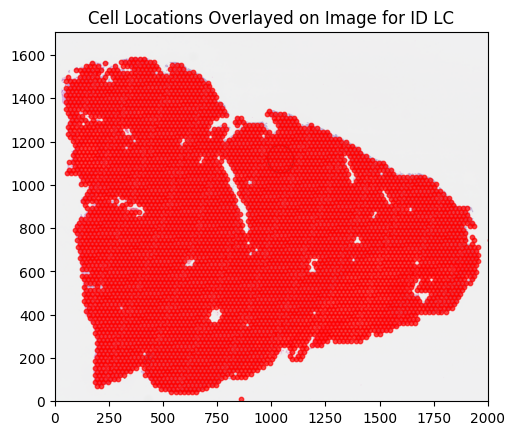

Processing ID Lscc: Image = /sibcb1/chenluonanlab8/zoujiawei/data_lung/10x/10x/images/Lscc.png, Spatial Data = /sibcb1/chenluonanlab8/zoujiawei/data_lung/10x/10x/spot_Lscc.csv


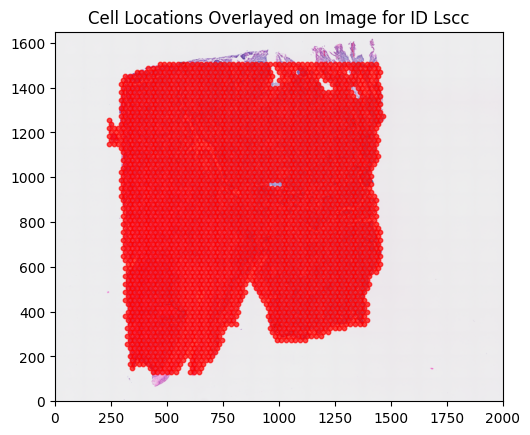

In [2]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

#def build_paths(base_path, ids, extension):
    #return [base_path + id + extension for id in ids]

#ids = "151507 151508 151509 151510 151669 151670 151671 151672 151673 151674 151675 151676".split()
#image_paths = build_paths("/sibcb1/chenluonanlab8/zoujiawei/Final version with foundation model/data/DLPFC/image/", ids, "_full_image.tif")

def build_paths(base_path, ids, extension, remove_prefix=None):
    """Builds file paths, optionally removing a prefix from IDs.

    Args:
        base_path: Base directory path (should end with '/').
        ids: List of IDs (strings).
        extension: File extension (including the leading dot '.').
        remove_prefix: Prefix to remove from IDs (string, or None if no removal).

    Returns:
        List of file paths.  Returns an empty list if input is invalid or an error occurs.
    """
    try:

        cleaned_ids = [id.replace(remove_prefix, "") if remove_prefix else id for id in ids]

        return [base_path + id + extension for id in cleaned_ids]

    except Exception as e:
        print(f"An error occurred: {e}")
        return []

#eg cccrcc
ids = ['LC', 'Lscc']

image_paths = build_paths("/sibcb1/chenluonanlab8/zoujiawei/data_lung/10x/10x/images/", ids, ".png")
spatial_pos_paths = build_paths("/sibcb1/chenluonanlab8/zoujiawei/data_lung/10x/10x/spot_", ids, ".csv", remove_prefix="standardized_")


for i, (img_path, spot_path) in enumerate(zip(image_paths, spatial_pos_paths)):
    print(f"Processing ID {ids[i]}: Image = {img_path}, Spatial Data = {spot_path}")
    try:
        #Read spatial data
        spatial_info = pd.read_csv(spot_path)
        # Extract x and y coordinates.  Error handling added for robustness.
        try:
            x_coords = spatial_info['pixel_x'].astype(int).tolist()  # Assuming 'v1' is the x-coordinate column
            y_coords = spatial_info['pixel_y'].astype(int).tolist()  # Assuming 'v2' is the y-coordinate column
        except KeyError as e:
            print(f"Error: Column not found in CSV {spot_path}: {e}")
            continue #skip to next ID
        except ValueError as e:
            print(f"Error converting to integer in CSV {spot_path}: {e}")
            continue #skip to next ID
        except pd.errors.EmptyDataError:
            print(f"Error: CSV file {spot_path} is empty.")
            continue

        # Read the image
        img = mpimg.imread(img_path)

        # Check if image was read correctly
        if img is None:
            print(f"Error: Could not read image file {img_path}")
            continue

        # Create the plot
        fig, ax = plt.subplots(1)
        ax.imshow(img)

        # Overlay the spot coordinates
        ax.scatter(x_coords, y_coords, s=10, c='red', marker='o', alpha=0.7)

        # Set the title and show the plot.  Handles potential issues with image dimensions.
        plt.title(f'Cell Locations Overlayed on Image for ID {ids[i]}')
        try:
            plt.xlim(0,img.shape[1]) #set limits to image size.
            plt.ylim(0,img.shape[0]) #set limits to image size
            plt.show()
        except AttributeError as e:
            print(f"Error displaying image for ID {ids[i]}: {e}.  Check image dimensions.")
            continue


    except FileNotFoundError:
        print(f"Error: One or both files not found for ID {ids[i]}. Check your paths: {img_path}, {spot_path}")
    except Exception as e:
        print(f"An unexpected error occurred for ID {ids[i]}: {e}")


In [6]:
import scanpy as sc
import pandas as pd

# 读取数据 (以 .h5ad 文件为例)
#adata = sc.read_h5ad('your_data.h5ad')  # 替换为你的数据文件路径

# 如果您有 CSV 格式的表达矩阵，可以这样读取：
adata = sc.read_csv("/sibcb1/chenluonanlab8/zoujiawei/Final version with foundation model/data/BRCA/st/oricount_A1.csv")  

In [7]:
adata = adata.transpose()

In [8]:


# 确保数据已进行质量控制和预处理，如果未处理，可以添加以下步骤：
#sc.pp.filter_cells(adata, min_genes=200)  # 过滤掉检测到的基因少于200的细胞
#sc.pp.filter_genes(adata, min_cells=3)   # 过滤掉在少于3个细胞中表达的基因
sc.pp.normalize_total(adata)            # 标准化每个细胞中读取的总量
sc.pp.log1p(adata)                      # 对数据进行对数变换

# 识别高度变异基因
sc.pp.highly_variable_genes(adata, n_top_genes=2000)  # 默认提取2000个HVG

# 查询高度变异基因的布尔索引
hvg_mask = adata.var['highly_variable']

# 根据布尔值提取高度变异基因的基因名称
hvg_genes = adata.var_names[hvg_mask]
print(f"Number of highly variable genes: {len(hvg_genes)}")

Number of highly variable genes: 2000


In [14]:


# 保存高度变异基因的列表为 CSV 文件或 NumPy 的 .npy 文件
output_csv = 'highly_variable_genes_1000.csv'
output_npy = 'highly_variable_genes_1000.npy'

# 保存为 CSV
pd.DataFrame({'HVGs': hvg_genes[:1000]}).to_csv(output_csv, index=False)
print(f"HVGs saved to {output_csv}")

# 保存为 NumPy 数组
import numpy as np
np.save(output_npy, hvg_genes)
print(f"HVGs saved to {output_npy}")

HVGs saved to highly_variable_genes_1000.csv
HVGs saved to highly_variable_genes_1000.npy


In [11]:
hvg_genes[:300]

Index(['ISG15', 'AGRN', 'TNFRSF4', 'SCNN1D', 'DVL1', 'AURKAIP1', 'ANKRD65',
       'VWA1', 'TMEM240', 'MIB2',
       ...
       'EIF3F', 'AKIP1', 'ZNF143', 'SBF2', 'GALNT18', 'DKK3', 'SPON1', 'ABCC8',
       'LDHA', 'LDHC'],
      dtype='object', length=300)